# 🎬 Notebook 1: EDA & Data Exploration
**Entertainment & Media Analytics Project**

Dataset: **MovieLens 1M** — 1 million ratings from 6,000 users on 4,000 movies.

This notebook covers:
- Loading & preprocessing all three `.dat` files
- Rating distribution analysis
- Genre analysis
- User behaviour (gender, age, occupation)
- Temporal trends
- Genre × Age heatmap
- Long-tail power law analysis
- Saving all processed data for downstream notebooks

## 0. Setup & Seed

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_DIR      = '../datasets/raw/ml-1m'
PROCESSED_DIR = '../datasets/processed'
PLOT_DIR      = 'plots'
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,      exist_ok=True)

print('Directories ready.')
print('Data folder contents:', os.listdir(DATA_DIR))

Directories ready.
Data folder contents: ['movies.dat', 'ratings.dat', 'README', 'users.dat']


---
## 1. Load Raw Data

In [3]:
ratings = pd.read_csv(
    f'{DATA_DIR}/ratings.dat', sep='::', engine='python',
    names=['userId','movieId','rating','timestamp'], encoding='latin-1'
)
movies = pd.read_csv(
    f'{DATA_DIR}/movies.dat', sep='::', engine='python',
    names=['movieId','title','genres'], encoding='latin-1'
)
users = pd.read_csv(
    f'{DATA_DIR}/users.dat', sep='::', engine='python',
    names=['userId','gender','age','occupation','zip'], encoding='latin-1'
)

print(f'Ratings : {ratings.shape}')
print(f'Movies  : {movies.shape}')
print(f'Users   : {users.shape}')
ratings.head(3)

Ratings : (1000209, 4)
Movies  : (3883, 3)
Users   : (6040, 5)


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


---
## 2. Preprocessing

In [4]:
# Ratings: timestamp to datetime
ratings['datetime']  = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year']      = ratings['datetime'].dt.year
ratings['month']     = ratings['datetime'].dt.month
ratings['dayofweek'] = ratings['datetime'].dt.day_name()

# Movies: extract release year
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)$').astype(float)
movies['decade'] = (movies['release_year'] // 10 * 10).dropna().astype('Int64').astype(str) + 's'

# Users: readable labels
age_map = {1:'Under 18',18:'18-24',25:'25-34',35:'35-44',45:'45-49',50:'50-55',56:'56+'}
occ_map = {
    0:'Other',1:'Academic/Educator',2:'Artist',3:'Clerical/Admin',
    4:'College/Grad Student',5:'Customer Service',6:'Doctor/Health Care',
    7:'Executive/Managerial',8:'Farmer',9:'Homemaker',10:'K-12 Student',
    11:'Lawyer',12:'Programmer',13:'Retired',14:'Sales/Marketing',
    15:'Scientist',16:'Self-Employed',17:'Technician/Engineer',
    18:'Tradesman/Craftsman',19:'Unemployed',20:'Writer'
}
users['age_group']        = users['age'].map(age_map)
users['occupation_label'] = users['occupation'].map(occ_map)

# Master merged df
master_df = (
    ratings
    .merge(movies[['movieId','title','genres','release_year']], on='movieId', how='left')
    .merge(users[['userId','gender','age_group','occupation_label']], on='userId', how='left')
)

# Exploded genres (one row per genre per movie)
movies_exploded = movies.copy()
movies_exploded['genre'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genre').reset_index(drop=True)

age_order = ['Under 18','18-24','25-34','35-44','45-49','50-55','56+']

print('Master df:', master_df.shape)
master_df.head(3)

Master df: (1000209, 14)


,userId,movieId,rating,timestamp,datetime,year,month,dayofweek,title,genres,release_year,gender,age_group,occupation_label
0,1,1193,5,978300760,2000-12-31 22:12:40,2000,12,Sunday,One Flew Over the Cuckoo's Nest (1975),Drama,1975.0,F,Under 18,K-12 Student
1,1,661,3,978302109,2000-12-31 22:35:09,2000,12,Sunday,James and the Giant Peach (1996),Animation|Children's|Musical,1996.0,F,Under 18,K-12 Student
2,1,914,3,978301968,2000-12-31 22:32:48,2000,12,Sunday,My Fair Lady (1964),Musical|Romance,1964.0,F,Under 18,K-12 Student


---
## 3. Basic Statistics

In [5]:
print('=== Dataset Overview ===')
print(f"Total ratings    : {len(ratings):,}")
print(f"Unique users     : {ratings['userId'].nunique():,}")
print(f"Unique movies    : {ratings['movieId'].nunique():,}")
print(f"Rating range     : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating      : {ratings['rating'].mean():.3f}")
print(f"Median rating    : {ratings['rating'].median():.1f}")
print(f"Date range       : {ratings['datetime'].min().date()} to {ratings['datetime'].max().date()}")
print()
print(ratings['rating'].value_counts().sort_index())

=== Dataset Overview ===
Total ratings    : 1,000,209
Unique users     : 6,040
Unique movies    : 3,706
Rating range     : 1 – 5
Mean rating      : 3.582
Median rating    : 4.0
Date range       : 2000-04-25 to 2003-02-28

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


---
## 4. Rating Distribution

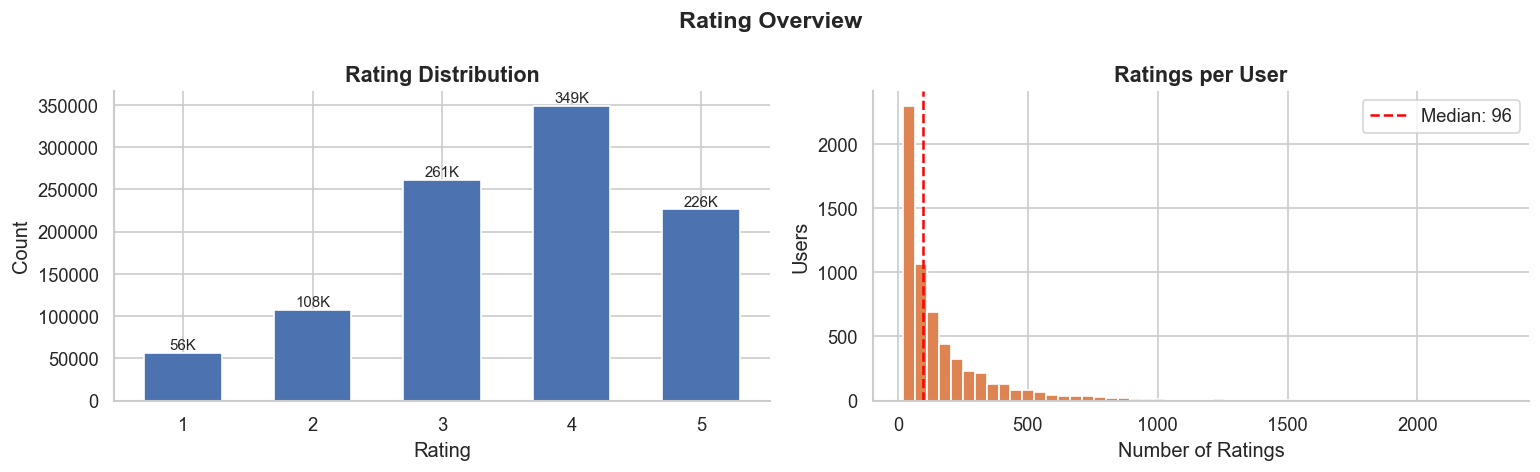

Saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rc = ratings['rating'].value_counts().sort_index()
axes[0].bar(rc.index.astype(str), rc.values, color='#4C72B0', edgecolor='white', width=0.6)
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
for i, v in enumerate(rc.values):
    axes[0].text(i, v + 4000, f'{v/1e3:.0f}K', ha='center', fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

rpu = ratings.groupby('userId')['rating'].count()
axes[1].hist(rpu, bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings'); axes[1].set_ylabel('Users')
axes[1].axvline(rpu.median(), color='red', linestyle='--', label=f'Median: {rpu.median():.0f}')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Rating Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_rating_distribution.png', bbox_inches='tight')
plt.show()
print('Saved.')

---
## 5. Genre Analysis

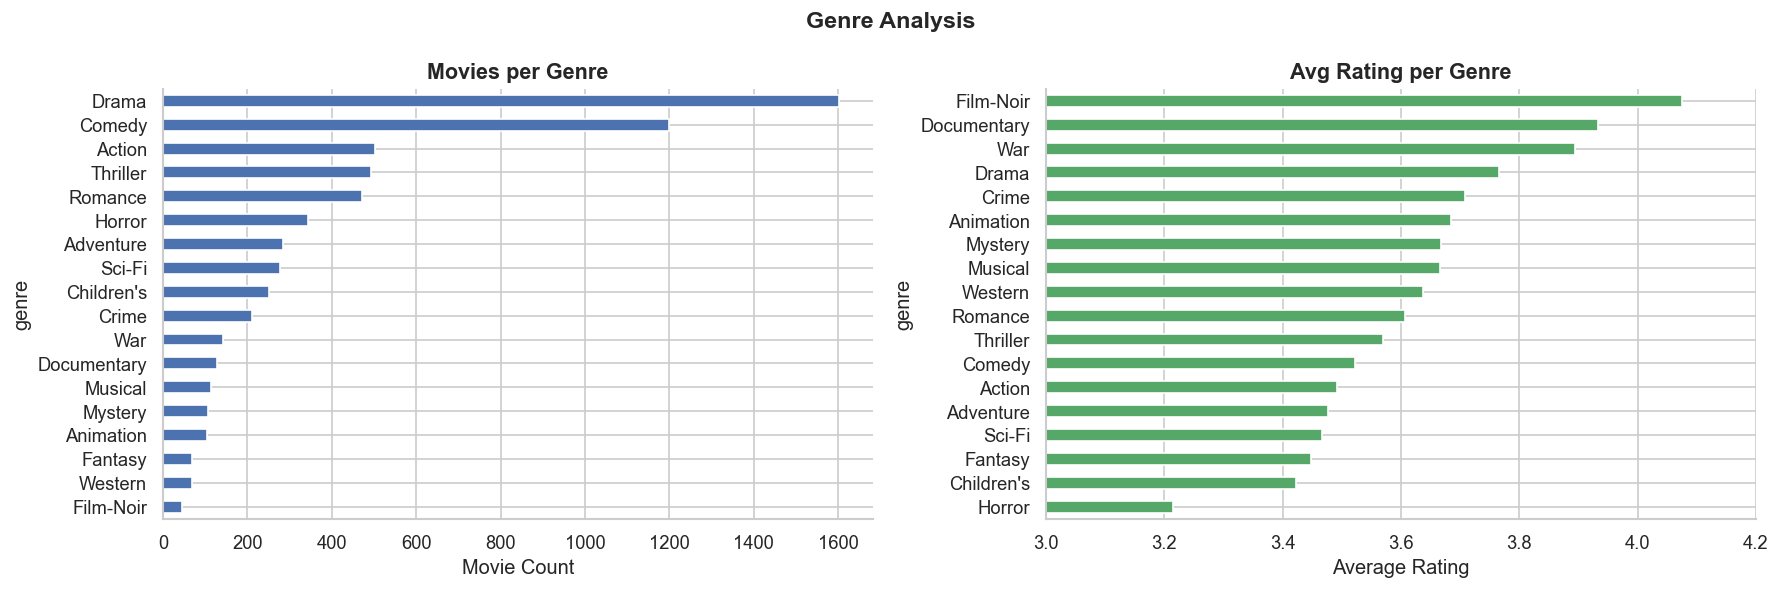

Saved.


In [7]:
genre_counts  = movies_exploded['genre'].value_counts()
genre_ratings = (
    ratings.merge(movies_exploded[['movieId','genre']], on='movieId', how='left')
    .groupby('genre')['rating'].mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

genre_counts.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Movies per Genre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Movie Count'); axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)

genre_ratings.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Avg Rating per Genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.0, 4.2); axes[1].invert_yaxis()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Genre Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_genre_analysis.png', bbox_inches='tight')
plt.show()
print('Saved.')

---
## 6. User Behaviour

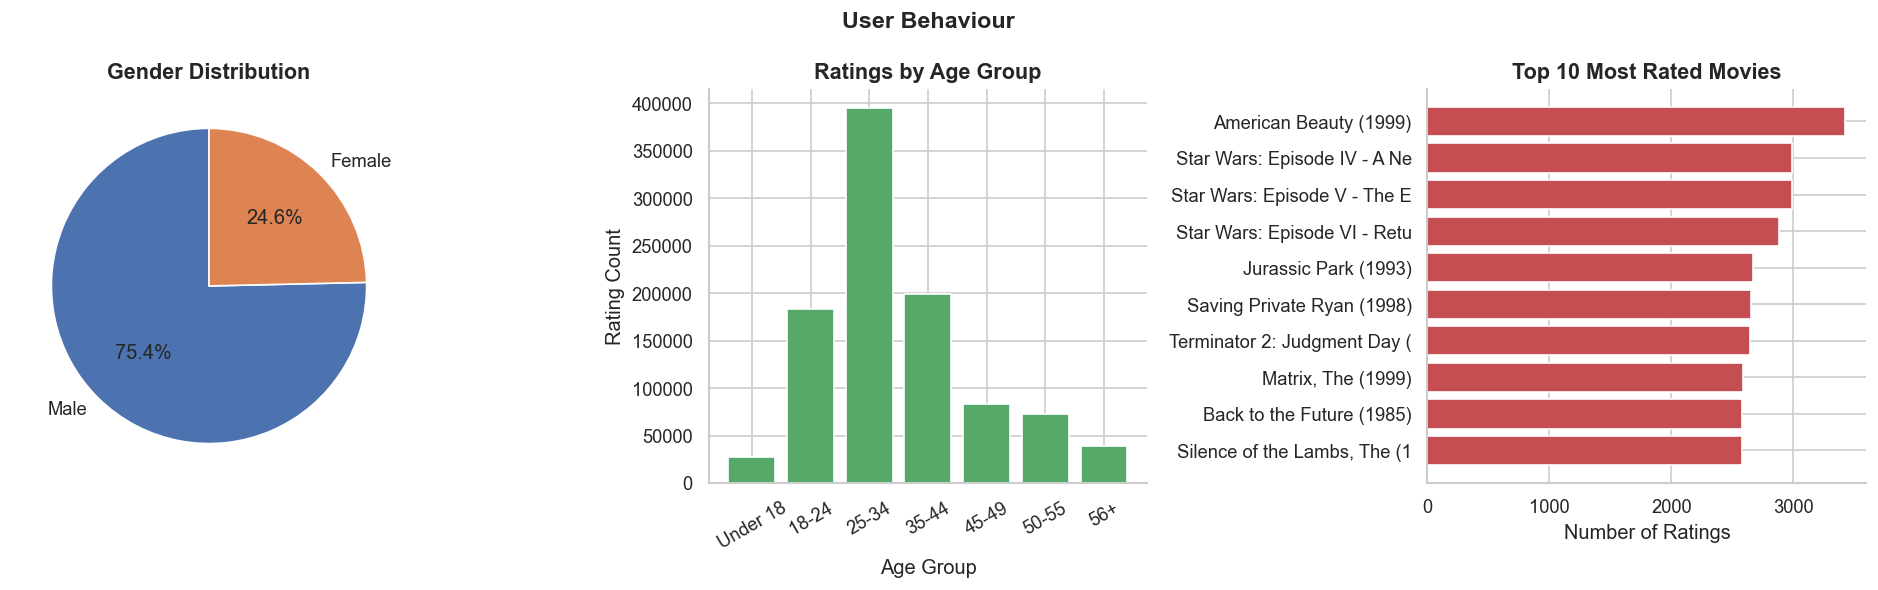

Saved.


In [8]:
user_ratings = ratings.merge(users[['userId','gender','age_group','occupation_label']], on='userId')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gender_counts = user_ratings['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=['Male','Female'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Gender Distribution', fontsize=13, fontweight='bold')

age_data = user_ratings.groupby('age_group')['rating'].count().reindex(age_order)
axes[1].bar(age_data.index, age_data.values, color='#55A868', edgecolor='white')
axes[1].set_title('Ratings by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Rating Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

top_movies = (
    ratings.groupby('movieId')['rating'].count().reset_index()
    .merge(movies[['movieId','title']], on='movieId')
    .sort_values('rating', ascending=False).head(10)
)
top_movies['short'] = top_movies['title'].str[:28]
axes[2].barh(top_movies['short'], top_movies['rating'], color='#C44E52')
axes[2].set_title('Top 10 Most Rated Movies', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Ratings'); axes[2].invert_yaxis()
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('User Behaviour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_user_behavior.png', bbox_inches='tight')
plt.show()
print('Saved.')

---
## 7. Temporal Trends

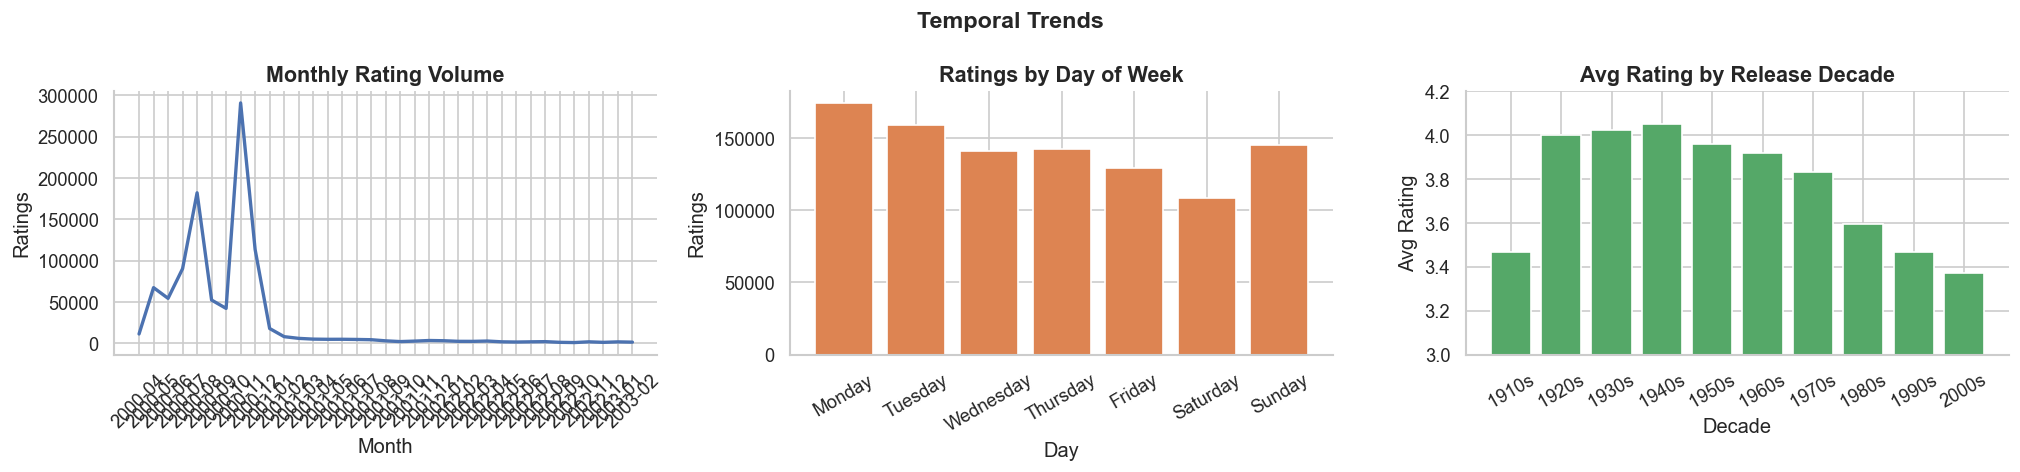

Saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

monthly = ratings.groupby(ratings['datetime'].dt.to_period('M'))['rating'].count()
monthly.index = monthly.index.astype(str)
axes[0].plot(monthly.index, monthly.values, linewidth=2, color='#4C72B0')
axes[0].set_title('Monthly Rating Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Ratings')
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top','right']].set_visible(False)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_data  = ratings['dayofweek'].value_counts().reindex(dow_order)
axes[1].bar(dow_data.index, dow_data.values, color='#DD8452', edgecolor='white')
axes[1].set_title('Ratings by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Ratings')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

decade_data = (
    ratings.merge(movies[['movieId','decade']], on='movieId', how='left')
    .dropna(subset=['decade'])
    .groupby('decade')['rating'].mean()
    .sort_index()
)
axes[2].bar(decade_data.index, decade_data.values, color='#55A868', edgecolor='white')
axes[2].set_title('Avg Rating by Release Decade', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Decade'); axes[2].set_ylabel('Avg Rating')
axes[2].set_ylim(3.0, 4.2)
axes[2].tick_params(axis='x', rotation=30)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Temporal Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_temporal_trends.png', bbox_inches='tight')
plt.show()
print('Saved.')

---
## 8. Genre × Age Group Heatmap

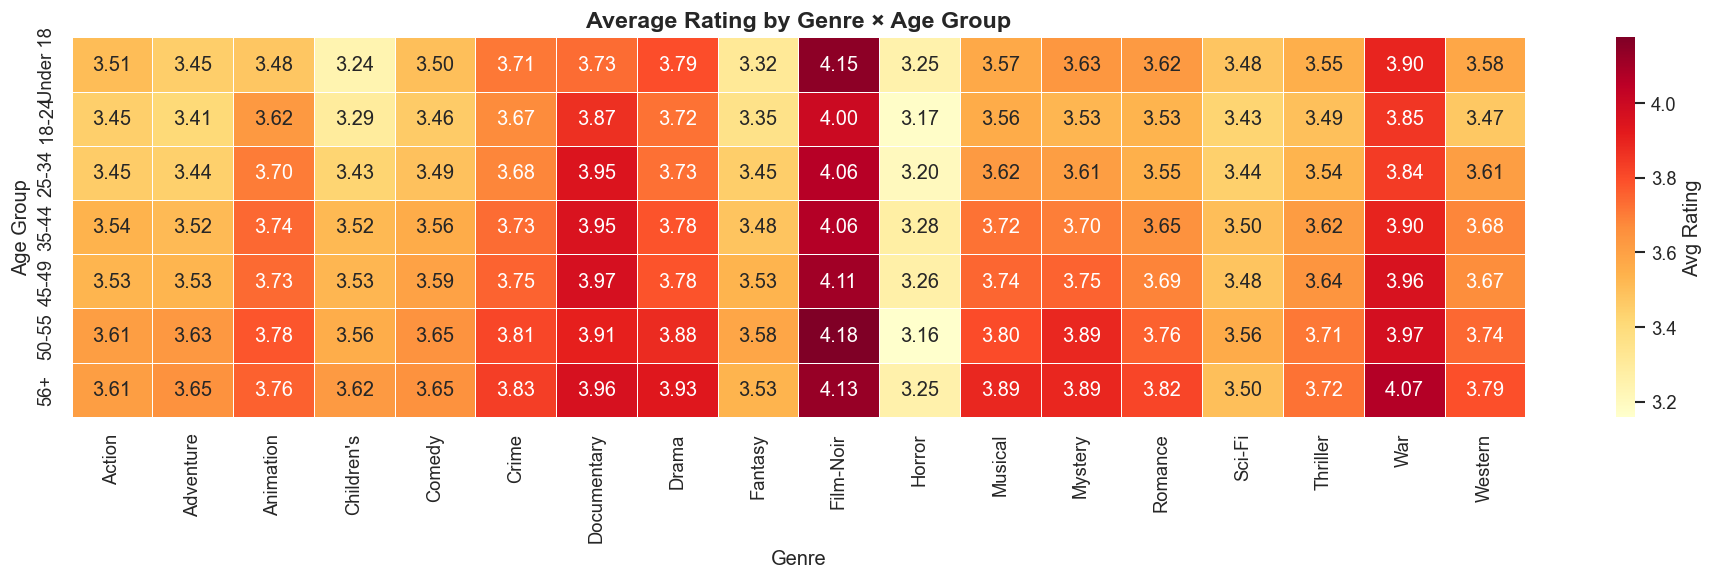

Saved.


In [10]:
heat_data = (
    master_df.merge(movies_exploded[['movieId','genre']], on='movieId', how='left')
    .groupby(['age_group','genre'])['rating'].mean()
    .unstack(fill_value=0)
    .reindex(age_order)
)

plt.figure(figsize=(16, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Avg Rating'}
)
plt.title('Average Rating by Genre × Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Genre'); plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_heatmap_genre_age.png', bbox_inches='tight')
plt.show()
print('Saved.')

---
## 9. Long-Tail Power Law

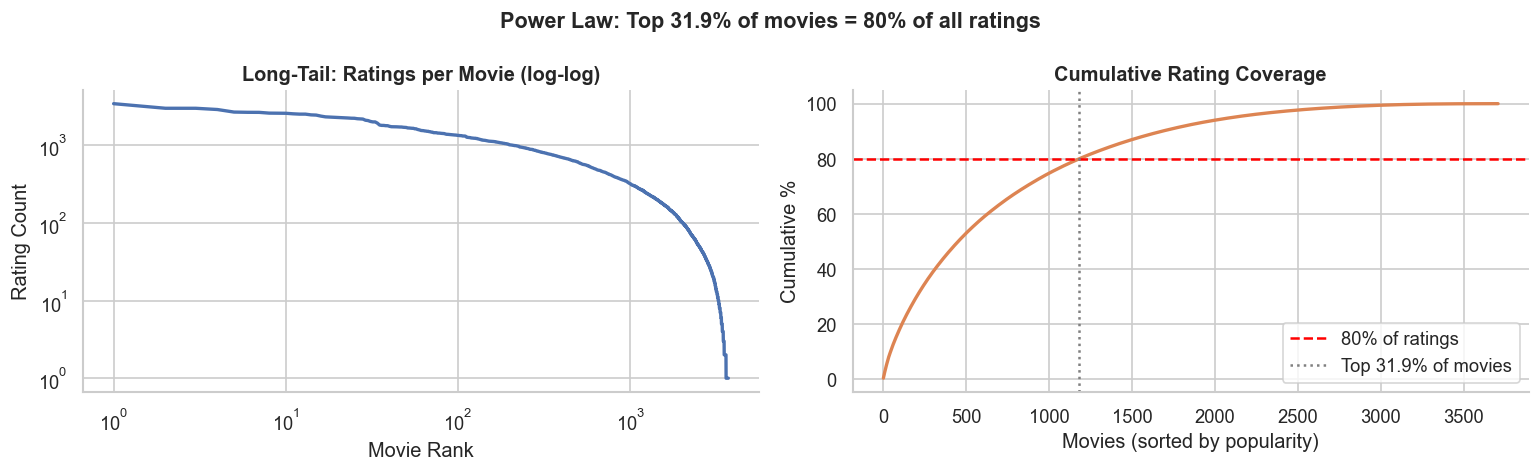

Top 31.9% of movies = 80% of ratings.


In [11]:
movie_counts = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
cumulative   = movie_counts.cumsum() / movie_counts.sum() * 100
n_80  = (cumulative <= 80).sum()
pct_80 = n_80 / len(movie_counts) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(range(1, len(movie_counts)+1), movie_counts.values, color='#4C72B0', linewidth=2)
axes[0].set_title('Long-Tail: Ratings per Movie (log-log)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Movie Rank'); axes[0].set_ylabel('Rating Count')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(range(1, len(cumulative)+1), cumulative.values, color='#DD8452', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', label='80% of ratings')
axes[1].axvline(n_80, color='gray', linestyle=':', label=f'Top {pct_80:.1f}% of movies')
axes[1].set_title('Cumulative Rating Coverage', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Movies (sorted by popularity)'); axes[1].set_ylabel('Cumulative %')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Power Law: Top {pct_80:.1f}% of movies = 80% of all ratings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_longtail.png', bbox_inches='tight')
plt.show()
print(f'Top {pct_80:.1f}% of movies = 80% of ratings.')

---
## 10. Save All Processed Data

In [12]:
ratings_clean = ratings[['userId','movieId','rating','datetime','year','month','dayofweek']]
movies_clean  = movies[['movieId','title','genres','release_year']].drop_duplicates('movieId')
users_clean   = users[['userId','gender','age','age_group','occupation','occupation_label']]

ratings_clean.to_csv(f'{PROCESSED_DIR}/ratings_clean.csv',    index=False)
movies_clean.to_csv(f'{PROCESSED_DIR}/movies_clean.csv',      index=False)
users_clean.to_csv(f'{PROCESSED_DIR}/users_clean.csv',        index=False)
master_df.to_csv(f'{PROCESSED_DIR}/master_df.csv',            index=False)
movies_exploded.to_csv(f'{PROCESSED_DIR}/movies_exploded.csv',index=False)

print('Saved to processed/:')
for f in sorted(os.listdir(PROCESSED_DIR)):
    kb = os.path.getsize(os.path.join(PROCESSED_DIR, f)) / 1024
    print(f'  {f:<35} {kb:>8.1f} KB')

Saved to processed/:
  OPTIMIZATION_REPORT.txt                  3.8 KB
  analytics_cache.json                     2.2 KB
  churn_feature_importance.csv             0.3 KB
  genre_clf_metrics.json                   0.5 KB
  genre_clf_metrics_final.json             1.2 KB
  genre_label_report.csv                   0.7 KB
  genre_performance_detailed.csv           1.2 KB
  genre_thresholds_optimized.csv           0.7 KB
  master_df.csv                       125082.1 KB
  movies_clean.csv                       192.1 KB
  movies_exploded.csv                    419.3 KB
  pop_feature_importance.csv               0.5 KB
  production_config.json                   4.0 KB
  production_thresholds.json               1.0 KB
  ratings_clean.csv                    46978.2 KB
  recommender_metrics.json                 0.3 KB
  sentiment_metrics.json                   0.2 KB
  sentiment_sample_preds.csv               1.3 KB
  user_genre_affinity.csv              56013.9 KB
  users_clean.csv            

---
## 11. Summary

In [13]:
print('=' * 50)
print('EDA COMPLETE — MovieLens 1M')
print('=' * 50)
print(f"Total ratings    : {len(ratings):,}")
print(f"Unique users     : {ratings['userId'].nunique():,}")
print(f"Unique movies    : {ratings['movieId'].nunique():,}")
print(f"Mean rating      : {ratings['rating'].mean():.3f}")
print(f"Top genre        : {genre_counts.index[0]}")
print(f"Power law        : Top {pct_80:.1f}% movies = 80% of ratings")
print()
print('Plots  → plots/')
print('CSVs   → processed/')
print()
print('Next step: Run 02_Recommendation_System.ipynb')

EDA COMPLETE — MovieLens 1M
Total ratings    : 1,000,209
Unique users     : 6,040
Unique movies    : 3,706
Mean rating      : 3.582
Top genre        : Drama
Power law        : Top 31.9% movies = 80% of ratings

Plots  → plots/
CSVs   → processed/

Next step: Run 02_Recommendation_System.ipynb
